<a href="https://colab.research.google.com/github/010Ankushsharma/Machine-learning-models-/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 20px; text-align: center; margin-bottom: 30px;">
  <h1 style="color: #e94560; font-size: 3em; margin-bottom: 10px; font-weight: 900;">📈 Multiple Linear Regression</h1>
  <h2 style="color: #a8dadc; font-size: 1.8em; margin-bottom: 20px;">Production-Quality ML Notebook</h2>
  <p style="color: #ccc; font-size: 1.1em;">Built by a Senior ML Engineer | Interview-Ready | Portfolio-Worthy</p>
  <hr style="border-color: #e94560; margin: 20px 0;">
  <p style="color: #a8dadc;">🏠 Dataset: California Housing | 🛠️ Stack: sklearn, pandas, seaborn, scipy | 🎯 Goal: End-to-End MLR Mastery</p>
</div>

---


---
## ⚙️ Environment Setup

Install any missing packages (safe to run on Colab or locally).

In [1]:
# ─────────────────────────────────────────────────────────────
# Install / upgrade required libraries
# ─────────────────────────────────────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn scipy statsmodels joblib
print("✅ All packages ready!")

✅ All packages ready!


In [2]:
# ─────────────────────────────────────────────────────────────
# Core Imports  — organised by responsibility
# ─────────────────────────────────────────────────────────────

# ── Data wrangling
import numpy as np
import pandas as pd

# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Statistics & diagnostics
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Sklearn — preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

# ── Sklearn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline

# ── Sklearn — metrics
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score)

# ── Model persistence
import joblib
import pickle
import warnings
import os

warnings.filterwarnings('ignore')

# ── Global plot style
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor' : '#0f0f0f',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#444',
    'axes.labelcolor'  : '#ccc',
    'xtick.color'      : '#aaa',
    'ytick.color'      : '#aaa',
    'text.color'       : '#eee',
    'grid.color'       : '#333',
    'axes.titlecolor'  : '#e94560',
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Imports complete. Notebook is ready to run!")

✅ Imports complete. Notebook is ready to run!


---
<a id='1-introduction'></a>

# 🟢 Section 1 — Introduction

<div style="background:#1a1a2e; border-left: 5px solid #e94560; padding:15px; border-radius:8px;">
  <b style="color:#e94560;">Goal:</b> Understand what regression is, why it matters, and when to use Multiple Linear Regression.
</div>

---

## 1.1 What is Regression?

**Regression** is a supervised machine learning technique used to predict a **continuous numerical output** (target variable) based on one or more **input features**.

> 💡 Think of regression as drawing the *best possible line (or plane) through your data* to make future predictions.

**Examples of regression problems:**
- Predicting house prices based on size, location, and bedrooms
- Forecasting sales revenue based on advertising spend
- Estimating salary based on years of experience and education
- Predicting stock prices (with many caveats!)

---

## 1.2 Simple vs Multiple Linear Regression

| Feature | Simple Linear Regression | Multiple Linear Regression |
|---------|--------------------------|-----------------------------|
| Input features | 1 | 2 or more |
| Equation | y = b₀ + b₁x | y = b₀ + b₁x₁ + b₂x₂ + … + bₙxₙ |
| Visual representation | 2D line | Hyperplane in N dimensions |
| Use case | 1 predictor, e.g. height → weight | Multiple predictors, e.g. all house attributes → price |
| Real-world applicability | Limited | High — almost all real problems have multiple features |

---

## 1.3 Real-World Use Cases

| Industry | Problem | Features Used |
|----------|---------|---------------|
| 🏠 Real Estate | Predict home price | sq_ft, rooms, location, age |
| 📊 Finance | Forecast revenue | ad spend, seasonality, market index |
| 🏥 Healthcare | Predict patient cost | age, BMI, smoking status, region |
| 🚗 Auto | Predict fuel efficiency | engine size, weight, horsepower |
| 📱 Tech | Predict user churn score | usage, tenure, support tickets |

---

## 1.4 When to Use MLR vs Other Models

```
Use MLR when:
  ✅  Target is continuous (price, salary, temperature)
  ✅  Relationship between features and target is approximately linear
  ✅  You need interpretability (coefficients explain impact)
  ✅  Dataset is relatively small-medium sized
  ✅  Baseline model before trying complex algorithms

Avoid MLR when:
  ❌  Target is categorical  →  use Logistic Regression / Classification
  ❌  Highly non-linear relationships  →  use Polynomial / Tree models
  ❌  Very high-dimensional sparse data  →  use Lasso / ElasticNet
  ❌  Complex pattern recognition  →  use Neural Networks
```

<div style="background:#1a1a2e; border-left:5px solid #f4c430; padding:15px; border-radius:8px; margin-top:20px;">
  <b style="color:#f4c430;">🎤 Interview Tip #1:</b><br>
  Always start with a simple baseline model like Linear Regression. If you jump straight to XGBoost without trying LinearRegression, interviewers will question your ML thought process. Linear Regression is your benchmark.
</div>

---
<a id='2-mathematical-foundation'></a>

# 🟡 Section 2 — Mathematical Foundation

<div style="background:#1a1a2e; border-left: 5px solid #00b4d8; padding:15px; border-radius:8px;">
  <b style="color:#00b4d8;">Goal:</b> Build intuition for the math powering Linear Regression — from hypothesis to gradient descent.
</div>

---

## 2.1 Hypothesis Function

The core equation of Multiple Linear Regression:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

- $\hat{y}$ = predicted output
- $\beta_0$ = **intercept** (bias term) — value of y when all x = 0
- $\beta_1, \beta_2, ..., \beta_n$ = **coefficients** (weights) — change in y per unit change in xᵢ, holding others constant
- $x_1, x_2, ..., x_n$ = input features

---

## 2.2 Matrix (Vectorized) Form

For a dataset with `m` samples and `n` features:

$$\hat{\mathbf{y}} = \mathbf{X} \boldsymbol{\beta}$$

Where:
- $\mathbf{X}$ is the design matrix of shape (m × (n+1)) — includes a column of 1s for the bias
- $\boldsymbol{\beta}$ is the parameter vector of shape ((n+1) × 1)

**Normal Equation (Closed-form solution):**

$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

> ⚠️ The Normal Equation is O(n³) for matrix inversion — gets slow for n > 10,000 features. That's when Gradient Descent is preferred.

---

## 2.3 Cost Function — Mean Squared Error (MSE)

We want to find $\boldsymbol{\beta}$ that minimises prediction error:

$$J(\boldsymbol{\beta}) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2 = \frac{1}{2m} \|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|^2$$

- Squaring penalises large errors more heavily
- The ½ simplifies the gradient derivative
- It's a **convex function** — guaranteed to have a single global minimum

---

## 2.4 Gradient Descent

Iteratively update parameters to minimise J:

$$\boldsymbol{\beta} := \boldsymbol{\beta} - \alpha \nabla J(\boldsymbol{\beta})$$

The gradient:
$$\frac{\partial J}{\partial \boldsymbol{\beta}} = \frac{1}{m} \mathbf{X}^T (\mathbf{X}\boldsymbol{\beta} - \mathbf{y})$$

- $\alpha$ = **learning rate** (step size). Too large → overshoot. Too small → slow convergence.
- We repeat until convergence (change in J < threshold)

---

## 2.5 The 5 Key Assumptions of Linear Regression

```
1. LINEARITY         — The relationship between X and y is linear
2. INDEPENDENCE      — Observations are independent of each other (no autocorrelation)
3. HOMOSCEDASTICITY  — Constant variance of residuals across all predicted values
4. NO MULTICOLLINEARITY — Features are not highly correlated with each other
5. NORMALITY         — Residuals (errors) follow a normal distribution
```

<div style="background:#1a1a2e; border-left:5px solid #e94560; padding:15px; border-radius:8px; margin-top:20px;">
  <b style="color:#e94560;">⚠️ Common Mistake #1:</b><br>
  Most beginners build the model and stop at R² score, completely ignoring assumption checking. In interviews, this is a red flag. Always verify your assumptions AFTER building the model. We'll do this in Section 8.
</div>

<div style="background:#1a1a2e; border-left:5px solid #f4c430; padding:15px; border-radius:8px; margin-top:10px;">
  <b style="color:#f4c430;">🎤 Interview Tip #2:</b><br>
  If an interviewer asks "What are the assumptions of Linear Regression?" — don't just list them. Explain what happens when each assumption is violated and how to fix it. That's what separates a junior from a senior.
</div>

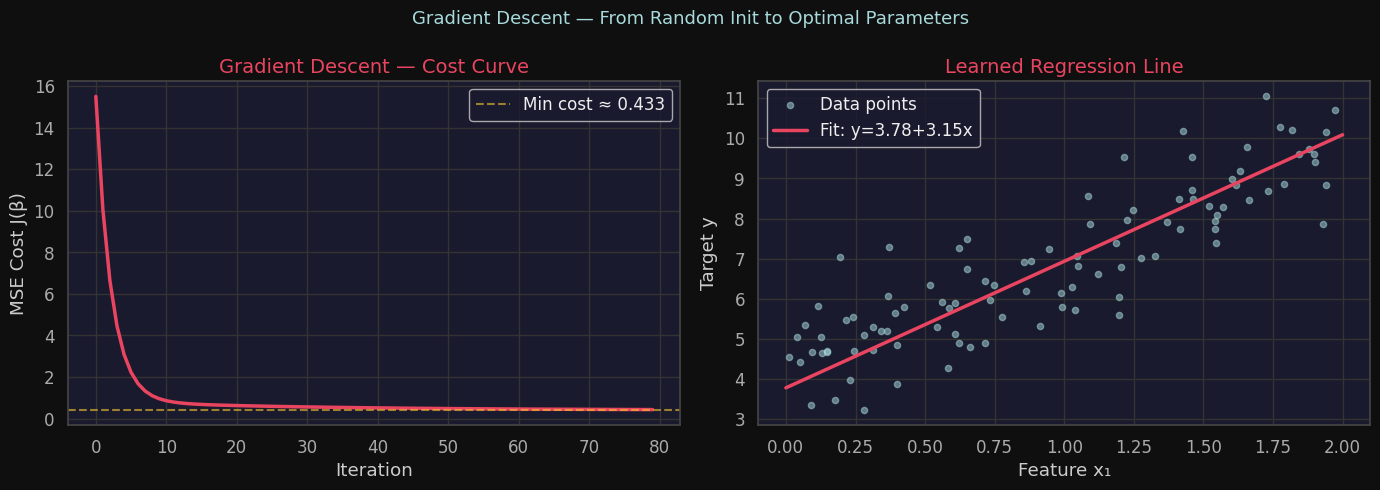


✅ Gradient Descent Results:
   True parameters:    β₀=4.0, β₁=3.0
   Learned parameters: β₀=3.7808, β₁=3.1536


In [3]:
# ─────────────────────────────────────────────────────────────
# Visualise Gradient Descent on a 2D cost surface
# This helps build intuition for how the optimiser works
# ─────────────────────────────────────────────────────────────

# Simulate a simple 1-feature regression dataset
np.random.seed(42)
X_demo = 2 * np.random.rand(100, 1)
y_demo = 4 + 3 * X_demo.ravel() + np.random.randn(100)

# Implement batch gradient descent manually
def gradient_descent(X, y, lr=0.1, n_iter=50):
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]          # add bias column
    beta = np.random.randn(X_b.shape[1])      # random init
    history = []
    for _ in range(n_iter):
        residuals = X_b @ beta - y
        cost = (1 / (2 * m)) * np.sum(residuals ** 2)
        grad = (1 / m) * X_b.T @ residuals
        beta -= lr * grad
        history.append({'cost': cost, 'beta': beta.copy()})
    return beta, history

beta_final, history = gradient_descent(X_demo, y_demo, lr=0.1, n_iter=80)
costs = [h['cost'] for h in history]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')

# Left: Cost curve
axes[0].plot(costs, color='#e94560', linewidth=2.5)
axes[0].set_title('Gradient Descent — Cost Curve', fontsize=14)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Cost J(β)')
axes[0].axhline(y=min(costs), color='#f4c430', linestyle='--', alpha=0.6, label=f'Min cost ≈ {min(costs):.3f}')
axes[0].legend()

# Right: Regression fit
axes[1].scatter(X_demo, y_demo, alpha=0.5, color='#a8dadc', s=20, label='Data points')
X_line = np.linspace(0, 2, 100)
axes[1].plot(X_line, beta_final[0] + beta_final[1] * X_line,
             color='#e94560', linewidth=2.5, label=f'Fit: y={beta_final[0]:.2f}+{beta_final[1]:.2f}x')
axes[1].set_title('Learned Regression Line', fontsize=14)
axes[1].set_xlabel('Feature x₁')
axes[1].set_ylabel('Target y')
axes[1].legend()

for ax in axes:
    ax.set_facecolor('#1a1a2e')

plt.suptitle('Gradient Descent — From Random Init to Optimal Parameters', fontsize=13, color='#a8dadc')
plt.tight_layout()
plt.show()

print(f"\n✅ Gradient Descent Results:")
print(f"   True parameters:    β₀=4.0, β₁=3.0")
print(f"   Learned parameters: β₀={beta_final[0]:.4f}, β₁={beta_final[1]:.4f}")

---
<a id='3-dataset-loading'></a>

# 🟢 Section 3 — Dataset Loading & Understanding

<div style="background:#1a1a2e; border-left: 5px solid #57cc99; padding:15px; border-radius:8px;">
  <b style="color:#57cc99;">Dataset: California Housing (sklearn)</b><br>
  ~20,000 census block groups from California (1990). Target: median house value (in $100k units).
</div>

### Feature Dictionary

| Feature | Description | Type |
|---------|-------------|------|
| `MedInc` | Median income of households (in $10k) | Continuous |
| `HouseAge` | Median house age in block group | Continuous |
| `AveRooms` | Average number of rooms per household | Continuous |
| `AveBedrms` | Average number of bedrooms per household | Continuous |
| `Population` | Block group population | Continuous |
| `AveOccup` | Average number of household members | Continuous |
| `Latitude` | Block group latitude | Continuous |
| `Longitude` | Block group longitude | Continuous |
| `MedHouseVal` | **TARGET** — Median house value in $100,000s | Continuous |

In [4]:
# ─────────────────────────────────────────────────────────────
# Load California Housing Dataset
# ─────────────────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)

# Build a single DataFrame with target included
df = housing.frame.copy()
print("Dataset shape:", df.shape)
print("Target column: MedHouseVal (median house value in $100,000)\n")
df.head()

Dataset shape: (20640, 9)
Target column: MedHouseVal (median house value in $100,000)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# ─────────────────────────────────────────────────────────────
# Dataset Quick Overview
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("TAIL (last 5 rows)")
print("=" * 60)
print(df.tail())

print("\n" + "=" * 60)
print("INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df.describe().T.style.background_gradient(cmap='Blues').format("{:.3f}")

TAIL (last 5 rows)
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
20635    -121.09        0.781  
20636    -121.21        0.771  
20637    -121.22        0.923  
20638    -121.32        0.847  
20639    -121.24        0.894  

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 no

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.000,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.000,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.000,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.000,2.069,1.154,0.150,1.196,1.797,2.647,5.000


In [6]:
# ─────────────────────────────────────────────────────────────
# Check for missing values
# ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ No missing values found! Clean dataset.")
else:
    print("⚠️ Missing values detected:")
    print(missing_df)

print(f"\nDataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ No missing values found! Clean dataset.

Dataset dimensions: 20,640 rows × 9 columns
Memory usage: 1.42 MB


---
<a id='4-eda'></a>

# 🟡 Section 4 — Exploratory Data Analysis (EDA)

<div style="background:#1a1a2e; border-left: 5px solid #00b4d8; padding:15px; border-radius:8px;">
  <b style="color:#00b4d8;">EDA is the most important step before modelling.</b> Never skip it. It tells you:<br>
  • What your data looks like<br>
  • What preprocessing is needed<br>
  • Which features matter most<br>
  • What problems exist (outliers, skew, multicollinearity)
</div>

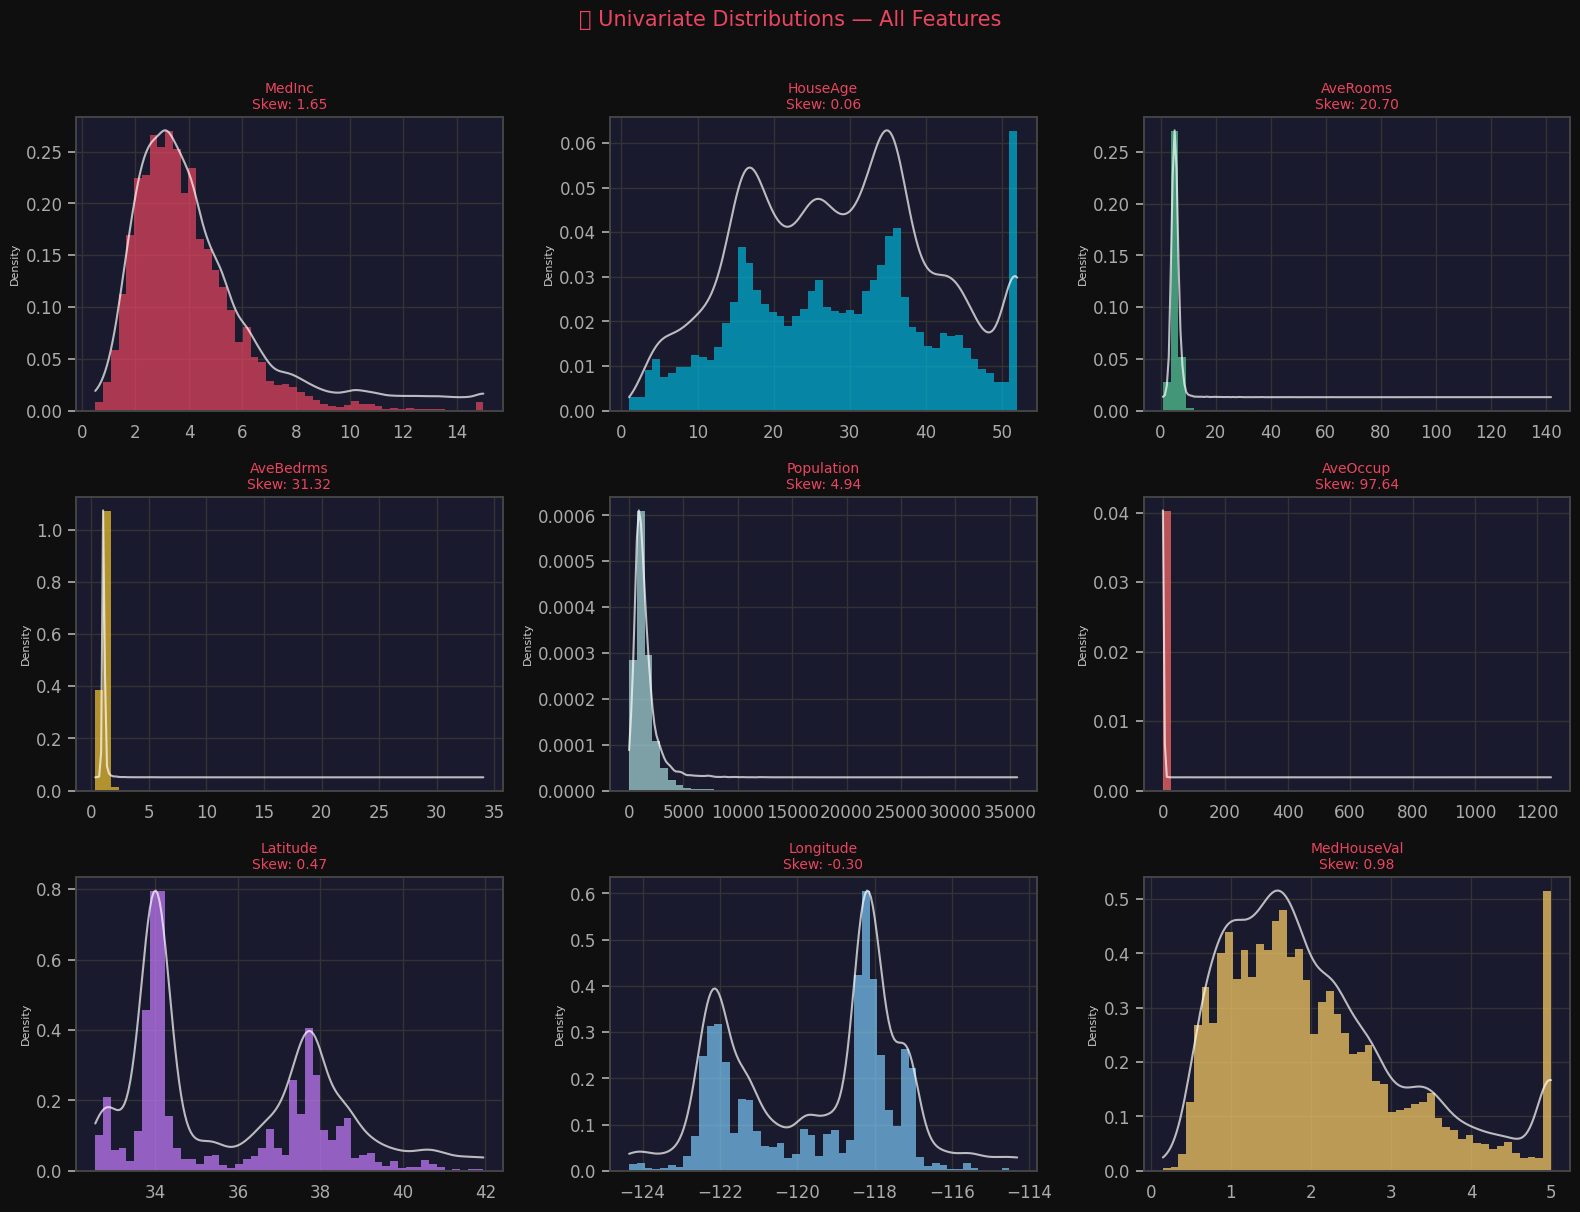


📋 Skewness Summary:
AveOccup       97.639561
AveBedrms      31.316956
AveRooms       20.697869
Population      4.935858
MedInc          1.646657
MedHouseVal     0.977763
Latitude        0.465953
HouseAge        0.060331
Longitude      -0.297801

💡 |Skew| > 1 means significantly skewed — consider log transform


In [7]:
# ─────────────────────────────────────────────────────────────
# 4.1 Univariate Analysis — distribution of each feature
# ─────────────────────────────────────────────────────────────
features = df.columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.ravel()

palette = ['#e94560', '#00b4d8', '#57cc99', '#f4c430',
           '#a8dadc', '#ff6b6b', '#c77dff', '#7bc8f6', '#ffd166']

for idx, (feature, color) in enumerate(zip(features, palette)):
    ax = axes[idx]
    ax.set_facecolor('#1a1a2e')

    # Histogram + KDE
    data = df[feature]
    ax.hist(data, bins=50, color=color, alpha=0.7, density=True, edgecolor='none')

    # Overlay KDE
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax2 = ax.twinx()
    ax2.plot(kde_x, kde(kde_x), color='white', linewidth=1.5, alpha=0.7)
    ax2.set_yticks([])
    ax2.set_facecolor('#1a1a2e')

    skewness = data.skew()
    ax.set_title(f'{feature}\nSkew: {skewness:.2f}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=8)

plt.suptitle('📊 Univariate Distributions — All Features', fontsize=15, color='#e94560', y=1.01)
plt.tight_layout()
plt.show()

print("\n📋 Skewness Summary:")
print(df.skew().sort_values(ascending=False).to_string())
print("\n💡 |Skew| > 1 means significantly skewed — consider log transform")

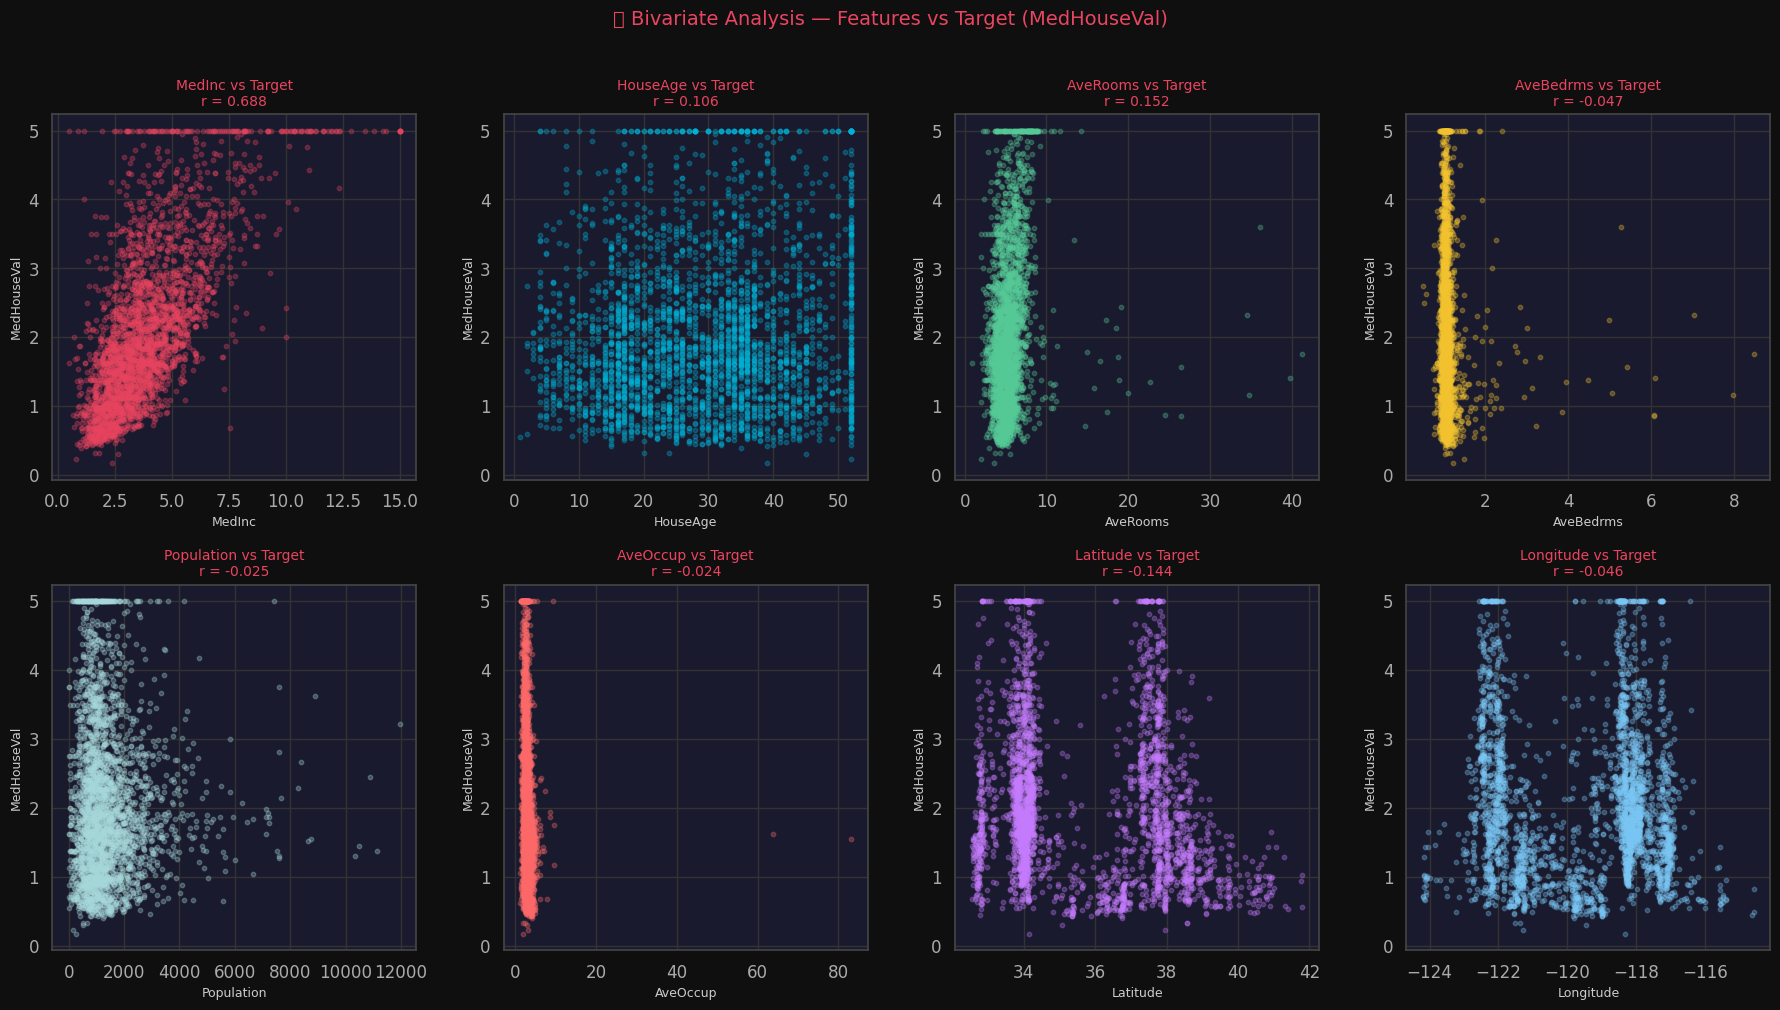

In [8]:
# ─────────────────────────────────────────────────────────────
# 4.2 Bivariate Analysis — each feature vs the target
# ─────────────────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'MedHouseVal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.ravel()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    ax.set_facecolor('#1a1a2e')

    # Sample 3000 points for plotting speed
    sample = df.sample(3000, random_state=42)
    ax.scatter(sample[feature], sample['MedHouseVal'],
               alpha=0.3, s=10, color=palette[idx])

    # Compute and show correlation
    corr = df[feature].corr(df['MedHouseVal'])
    ax.set_title(f'{feature} vs Target\nr = {corr:.3f}', fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('MedHouseVal', fontsize=9)

plt.suptitle('🔗 Bivariate Analysis — Features vs Target (MedHouseVal)',
             fontsize=14, color='#e94560', y=1.01)
plt.tight_layout()
plt.show()

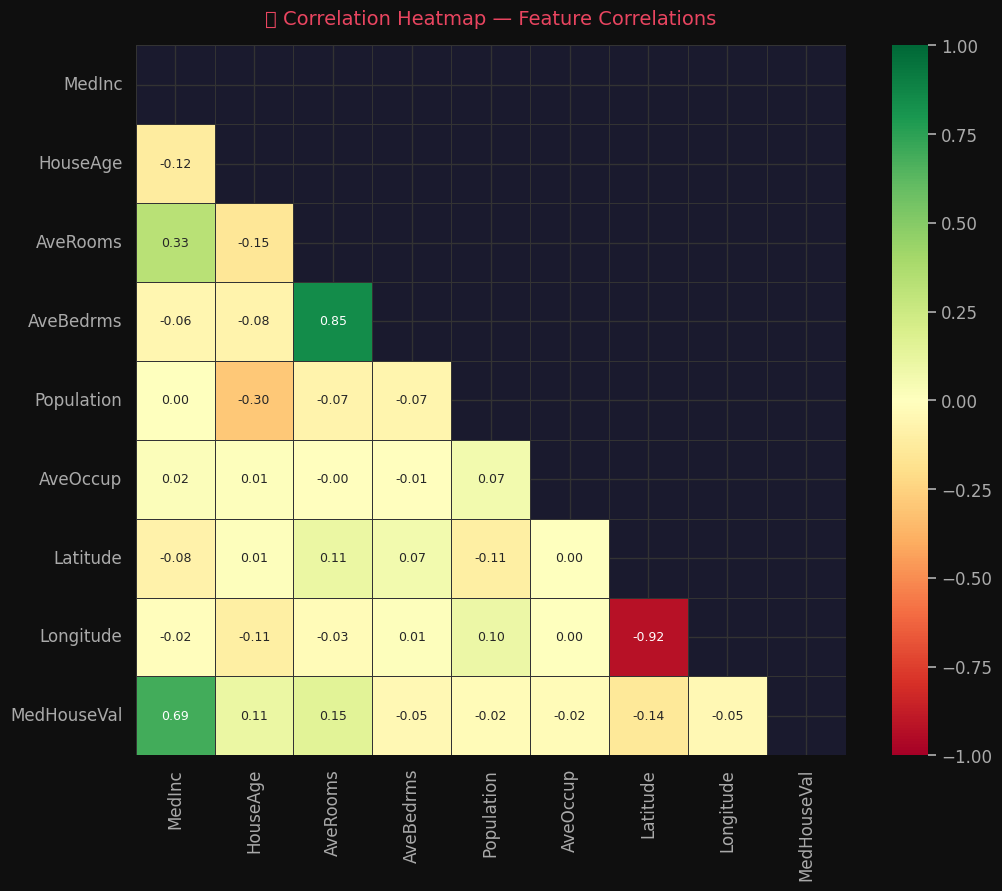


📊 Feature Correlations with Target (MedHouseVal):
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160

💡 MedInc has the strongest positive correlation with house value — makes economic sense!


In [9]:
# ─────────────────────────────────────────────────────────────
# 4.3 Correlation Heatmap — detect multicollinearity early
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

corr_matrix = df.corr()

# Create a mask for the upper triangle (avoid redundancy)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='#333',
    square=True,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('🔥 Correlation Heatmap — Feature Correlations', fontsize=14, color='#e94560', pad=15)
plt.tight_layout()
plt.show()

# Show top correlations with target
print("\n📊 Feature Correlations with Target (MedHouseVal):")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False).drop('MedHouseVal').to_string())
print("\n💡 MedInc has the strongest positive correlation with house value — makes economic sense!")

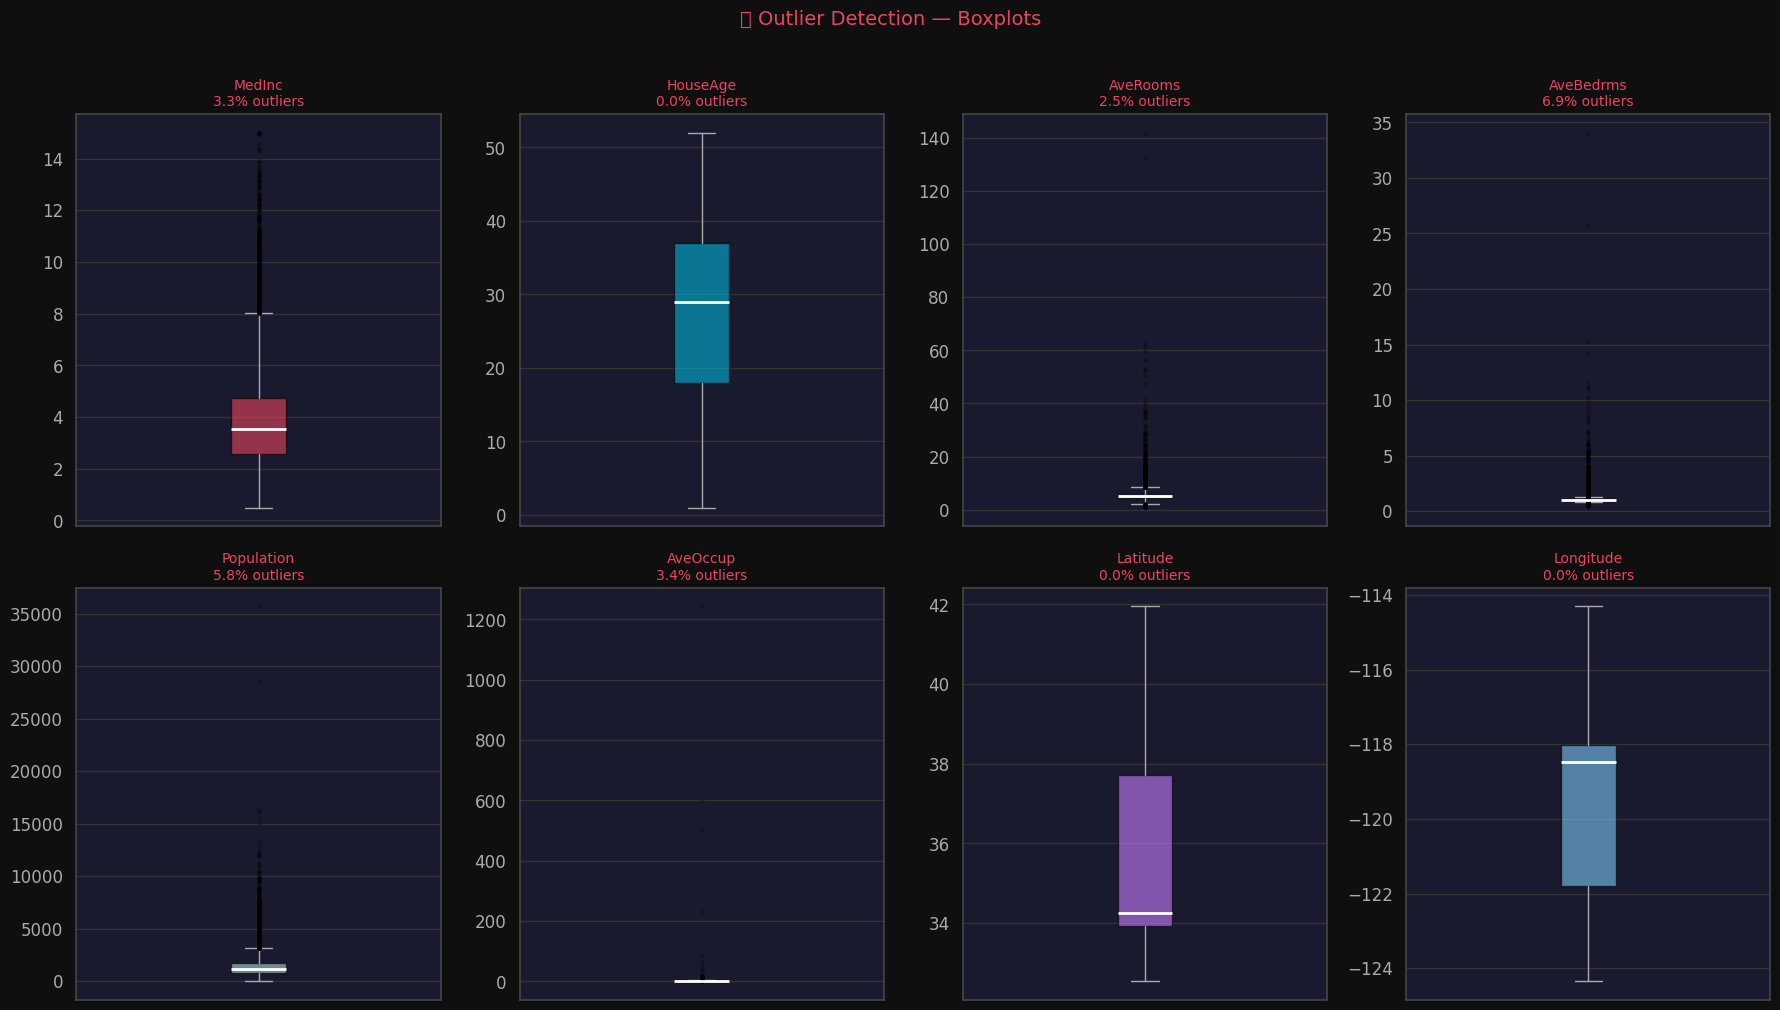


📊 Outlier Summary (% of data outside 1.5×IQR fence):
  AveBedrms         6.9%  █████████████
  Population        5.8%  ███████████
  AveOccup          3.4%  ██████
  MedInc            3.3%  ██████
  AveRooms          2.5%  ████
  HouseAge          0.0%  
  Latitude          0.0%  
  Longitude         0.0%  


In [10]:
# ─────────────────────────────────────────────────────────────
# 4.4 Outlier Detection — Boxplots with IQR summary
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.ravel()

outlier_summary = {}

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    ax.set_facecolor('#1a1a2e')

    Q1  = df[feature].quantile(0.25)
    Q3  = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    outlier_pct = len(outliers) / len(df) * 100
    outlier_summary[feature] = outlier_pct

    bp = ax.boxplot(df[feature], patch_artist=True,
                    boxprops=dict(facecolor=palette[idx], alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#aaa'),
                    capprops=dict(color='#aaa'),
                    flierprops=dict(marker='o', color='#e94560', alpha=0.3, markersize=2))

    ax.set_title(f'{feature}\n{outlier_pct:.1f}% outliers', fontsize=10)
    ax.set_xticks([])

plt.suptitle('📦 Outlier Detection — Boxplots', fontsize=14, color='#e94560', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 Outlier Summary (% of data outside 1.5×IQR fence):")
for feat, pct in sorted(outlier_summary.items(), key=lambda x: -x[1]):
    bar = '█' * int(pct * 2)
    print(f"  {feat:<15} {pct:5.1f}%  {bar}")

---
<a id='5-preprocessing'></a>

# 🟡 Section 5 — Data Preprocessing (Industry Level)

<div style="background:#1a1a2e; border-left: 5px solid #f4c430; padding:15px; border-radius:8px;">
  <b style="color:#f4c430;">Pro Tip:</b> Preprocessing is where 80% of a real ML engineer's time goes. A well-preprocessed dataset will always outperform a raw dataset regardless of the algorithm chosen.
</div>

In [11]:
# ─────────────────────────────────────────────────────────────
# 5.1  Separate features and target
# ─────────────────────────────────────────────────────────────
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature list: {list(X.columns)}")

Features shape : (20640, 8)
Target shape   : (20640,)

Feature list: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [12]:
# ─────────────────────────────────────────────────────────────
# 5.2  Cap outliers using the 1st–99th percentile (Winsorization)
#      Removes extreme values without losing rows
# ─────────────────────────────────────────────────────────────
X_clean = X.copy()

for col in X_clean.columns:
    p01 = X_clean[col].quantile(0.01)
    p99 = X_clean[col].quantile(0.99)
    X_clean[col] = X_clean[col].clip(lower=p01, upper=p99)

print("✅ Outlier capping complete (1st–99th percentile Winsorization)")
print(f"   Rows preserved: {len(X_clean):,} (no data loss)")

✅ Outlier capping complete (1st–99th percentile Winsorization)
   Rows preserved: 20,640 (no data loss)


In [13]:
# ─────────────────────────────────────────────────────────────
# 5.3  Train / Test Split (80/20)
#      CRITICAL: Split BEFORE scaling to prevent data leakage!
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train/Test Split (80/20):")
print(f"  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"  X_test : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"\n  Target distribution — Train mean: ${y_train.mean()*100_000:,.0f}")
print(f"  Target distribution — Test  mean: ${y_test.mean()*100_000:,.0f}")

Train/Test Split (80/20):
  X_train: (16512, 8)  |  y_train: (16512,)
  X_test : (4128, 8)   |  y_test : (4128,)

  Target distribution — Train mean: $207,195
  Target distribution — Test  mean: $205,500


In [14]:
# ─────────────────────────────────────────────────────────────
# 5.4  Feature Scaling — Standardization (Z-score)
#
#      StandardScaler: z = (x - mean) / std   →  mean=0, std=1
#      MinMaxScaler  : x' = (x-min)/(max-min) →  range [0, 1]
#
#      We use StandardScaler for Linear Regression (preferred
#      because it handles outliers better than MinMax)
#
#  ⚠️  Fit on TRAIN data only, then transform BOTH train & test
#      Never fit on test — that's data leakage!
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only

# Wrap back into DataFrames for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("✅ Feature Scaling Complete")
print("\nBefore scaling — MedInc stats:")
print(f"  Mean={X_train['MedInc'].mean():.4f}, Std={X_train['MedInc'].std():.4f}")
print("\nAfter scaling — MedInc stats:")
print(f"  Mean={X_train_scaled_df['MedInc'].mean():.4f}, Std={X_train_scaled_df['MedInc'].std():.4f}")

✅ Feature Scaling Complete

Before scaling — MedInc stats:
  Mean=3.8623, Std=1.8080

After scaling — MedInc stats:
  Mean=0.0000, Std=1.0000



VIF Analysis:

   Feature       VIF   Status
  Latitude 10.338258 ❌ Remove
 Longitude  9.814546  ⚠️ High
  AveRooms  3.543151     ✅ OK
    MedInc  3.171259     ✅ OK
 AveBedrms  1.863989     ✅ OK
  HouseAge  1.284522     ✅ OK
Population  1.206031     ✅ OK
  AveOccup  1.116647     ✅ OK


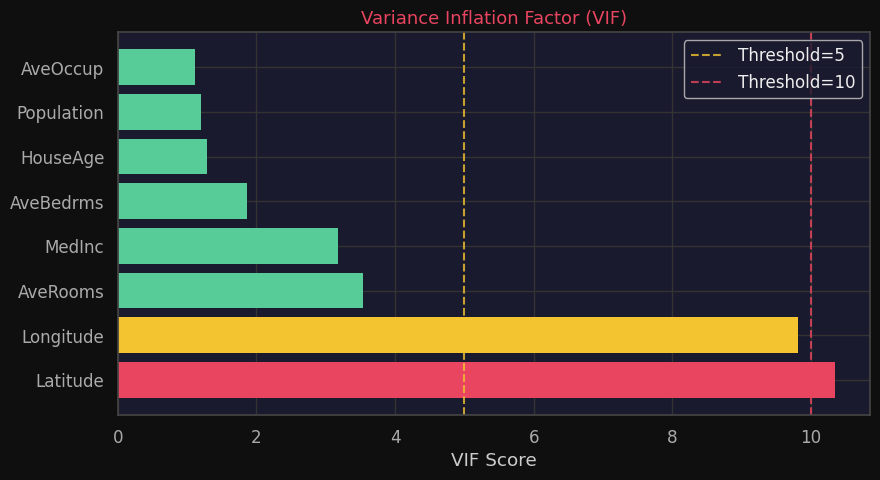

In [15]:
# ─────────────────────────────────────────────────────────────
# 5.5  Variance Inflation Factor (VIF) — Multicollinearity Check
#
#      VIF = 1        → No correlation (ideal)
#      VIF = 1–5      → Moderate — acceptable
#      VIF = 5–10     → High — investigate
#      VIF > 10       → Severe multicollinearity — remove feature!
#
#      VIF measures how much the variance of a coefficient
#      is inflated due to correlation with other features.
# ─────────────────────────────────────────────────────────────
def compute_vif(X_df):
    """Compute VIF for each feature in a scaled DataFrame."""
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_df.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_df.values, i)
        for i in range(X_df.shape[1])
    ]
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda v: '✅ OK' if v < 5 else ('⚠️ High' if v < 10 else '❌ Remove')
    )
    return vif_data.sort_values('VIF', ascending=False)

vif_df = compute_vif(X_train_scaled_df)
print("\nVIF Analysis:\n")
print(vif_df.to_string(index=False))

# Visualise VIF
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

colors = ['#e94560' if v > 10 else '#f4c430' if v > 5 else '#57cc99'
          for v in vif_df['VIF']]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, edgecolor='none')
ax.axvline(5,  color='#f4c430', linestyle='--', linewidth=1.5, alpha=0.8, label='Threshold=5')
ax.axvline(10, color='#e94560', linestyle='--', linewidth=1.5, alpha=0.8, label='Threshold=10')
ax.set_title('Variance Inflation Factor (VIF)', fontsize=13)
ax.set_xlabel('VIF Score')
ax.legend()
plt.tight_layout()
plt.show()

---
<a id='6-model-building'></a>

# 🟡 Section 6 — Model Building

<div style="background:#1a1a2e; border-left: 5px solid #57cc99; padding:15px; border-radius:8px;">
  We'll train the model using sklearn's <code>LinearRegression</code>, which internally uses the <b>Ordinary Least Squares (OLS)</b> method — the Normal Equation under the hood (not gradient descent by default).
</div>

In [16]:
# ─────────────────────────────────────────────────────────────
# 6.1  Train the Linear Regression Model
# ─────────────────────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print(f"\n  Intercept (β₀) : {lr_model.intercept_:.4f}")
print(f"  Meaning: When all features are at their mean, predicted house value = ${lr_model.intercept_*100_000:,.0f}\n")

✅ Model trained successfully!

  Intercept (β₀) : 2.0719
  Meaning: When all features are at their mean, predicted house value = $207,195



Model Coefficients (on standardised features):
   Feature  Coefficient  Direction  Impact ($)
  Latitude    -0.884614 ↓ Negative    -88461.0
    MedInc     0.873729 ↑ Positive     87373.0
 Longitude    -0.819571 ↓ Negative    -81957.0
  AveOccup    -0.258831 ↓ Negative    -25883.0
  AveRooms    -0.189392 ↓ Negative    -18939.0
 AveBedrms     0.182610 ↑ Positive     18261.0
  HouseAge     0.155515 ↑ Positive     15552.0
Population     0.049641 ↑ Positive      4964.0


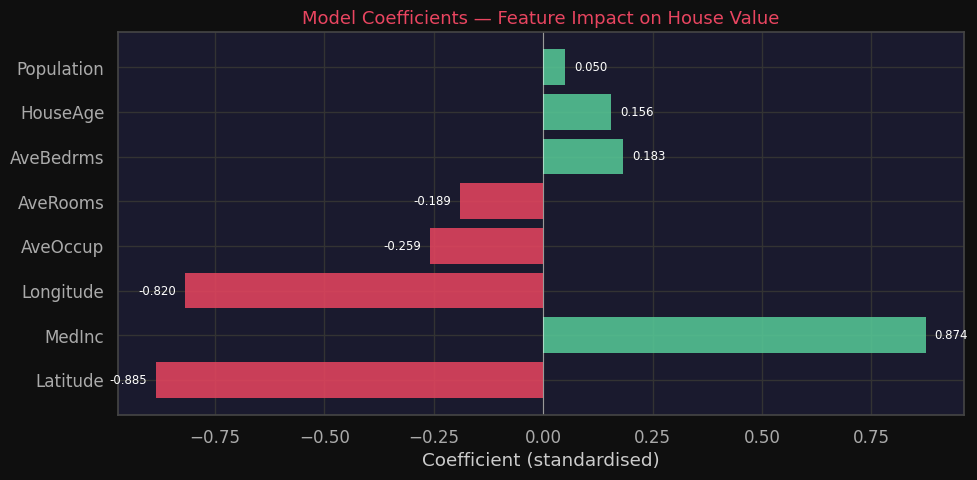


💡 Interpretation: Since features are standardised, coefficients are directly comparable.
   MedInc has the largest positive impact. Latitude & AveOccup have negative impacts.


In [17]:
# ─────────────────────────────────────────────────────────────
# 6.2  Analyse Coefficients
# ─────────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df['Direction'] = coef_df['Coefficient'].apply(lambda c: '↑ Positive' if c > 0 else '↓ Negative')
coef_df['Impact ($)'] = (coef_df['Coefficient'] * 100_000).round(0)

print("Model Coefficients (on standardised features):")
print(coef_df.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

colors = ['#57cc99' if c > 0 else '#e94560' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='none', alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax.set_title('Model Coefficients — Feature Impact on House Value', fontsize=13)
ax.set_xlabel('Coefficient (standardised)')

# Annotate
for i, (val, feat) in enumerate(zip(coef_df['Coefficient'], coef_df['Feature'])):
    ax.text(val + (0.02 if val >= 0 else -0.02), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8.5, color='white')

plt.tight_layout()
plt.show()

print("\n💡 Interpretation: Since features are standardised, coefficients are directly comparable.")
print("   MedInc has the largest positive impact. Latitude & AveOccup have negative impacts.")

---
<a id='7-evaluation'></a>

# 🟡 Section 7 — Model Evaluation (Very Detailed)

## Metrics Reference

| Metric | Formula | What it measures | Units |
|--------|---------|-----------------|-------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error | Same as target |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Average squared error (penalises large errors) | Target² |
| **RMSE** | $\sqrt{MSE}$ | Root of MSE (back to target units) | Same as target |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | % variance explained (0–1, higher=better) | Unitless |
| **Adj. R²** | $1 - (1-R^2)\frac{n-1}{n-p-1}$ | R² penalised for number of features | Unitless |

> 💡 **Adjusted R²** is more reliable than R² when comparing models with different numbers of features — it penalises adding useless features.

In [18]:
# ─────────────────────────────────────────────────────────────
# 7.1  Compute All Regression Metrics
# ─────────────────────────────────────────────────────────────
def regression_report(model, X_tr, X_te, y_tr, y_te, model_name='Model'):
    """Comprehensive regression evaluation report."""
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    def metrics(y_true, y_pred, label):
        n = len(y_true)
        p = X_tr.shape[1]  # number of features
        mae  = mean_absolute_error(y_true, y_pred)
        mse  = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(y_true, y_pred)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        return {
            'Set'      : label,
            'MAE'      : round(mae, 4),
            'MSE'      : round(mse, 4),
            'RMSE'     : round(rmse, 4),
            'R²'       : round(r2, 4),
            'Adj. R²'  : round(adj_r2, 4),
        }

    results = pd.DataFrame([metrics(y_tr, y_pred_train, 'Train'),
                             metrics(y_te, y_pred_test,  'Test')])
    print(f"\n{'='*60}")
    print(f"  {model_name} — Performance Report")
    print(f"{'='*60}")
    print(results.to_string(index=False))

    gap = results.loc[0,'R²'] - results.loc[1,'R²']
    print(f"\n  Train-Test R² Gap: {gap:.4f}", end=" ")
    if gap < 0.02:
        print("✅ Very low — model generalises well")
    elif gap < 0.05:
        print("⚠️ Moderate — slight overfitting")
    else:
        print("❌ High — significant overfitting")

    return model.predict(X_te)

y_pred = regression_report(lr_model, X_train_scaled, X_test_scaled,
                            y_train, y_test, model_name='LinearRegression')


  LinearRegression — Performance Report
  Set    MAE    MSE   RMSE     R²  Adj. R²
Train 0.4785 0.4283 0.6544 0.6796   0.6795
 Test 0.4882 0.4491 0.6702 0.6573   0.6566

  Train-Test R² Gap: 0.0223 ⚠️ Moderate — slight overfitting


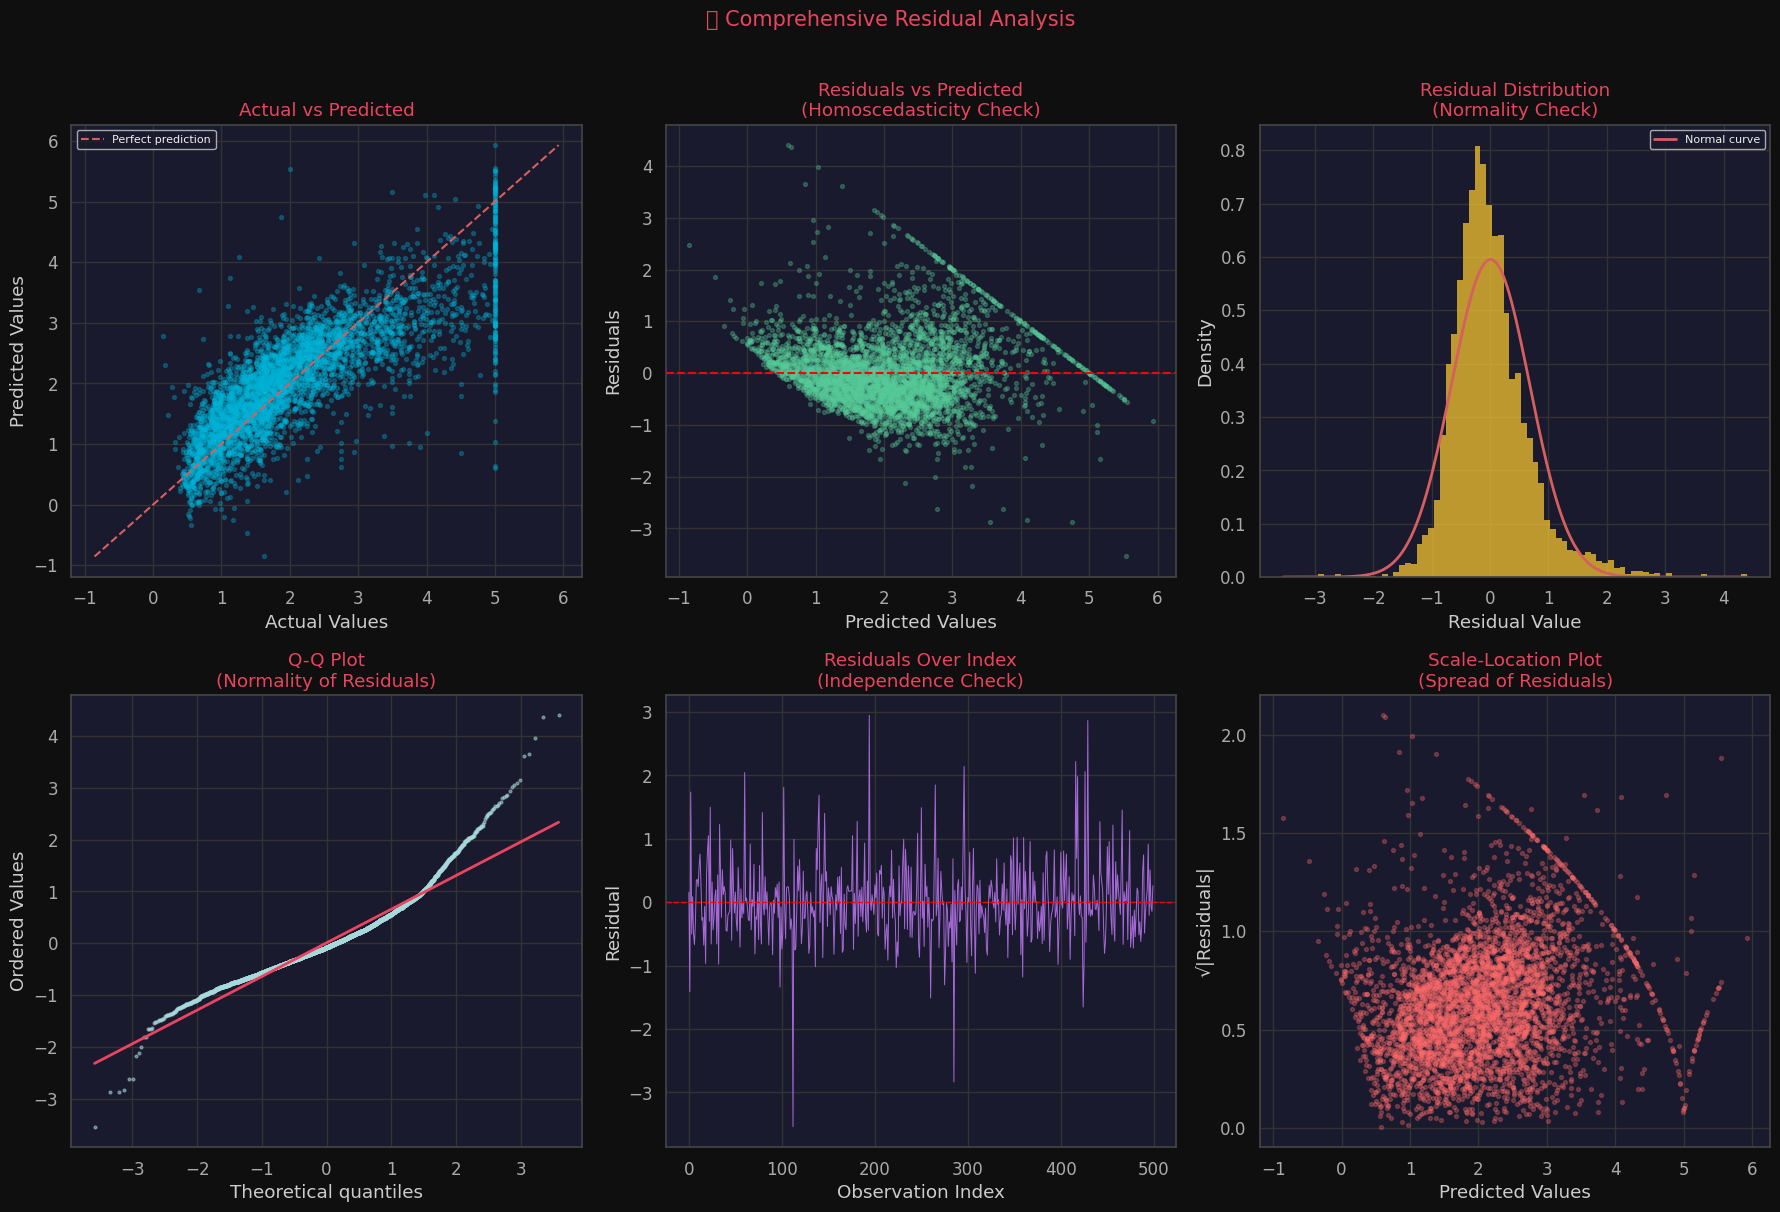

In [19]:
# ─────────────────────────────────────────────────────────────
# 7.2  Residual Analysis & Plots
# ─────────────────────────────────────────────────────────────
residuals = y_test.values - y_pred

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0f0f0f')
gs = gridspec.GridSpec(2, 3, figure=fig)

plot_configs = [
    (0, 0), (0, 1), (0, 2),
    (1, 0), (1, 1), (1, 2)
]

# ── Plot 1: Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1a2e')
ax1.scatter(y_test, y_pred, alpha=0.3, s=8, color='#00b4d8')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Values'); ax1.set_ylabel('Predicted Values')
ax1.set_title('Actual vs Predicted')
ax1.legend(fontsize=8)

# ── Plot 2: Residuals vs Predicted (homoscedasticity check)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1a2e')
ax2.scatter(y_pred, residuals, alpha=0.3, s=8, color='#57cc99')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted Values'); ax2.set_ylabel('Residuals')
ax2.set_title('Residuals vs Predicted\n(Homoscedasticity Check)')

# ── Plot 3: Residual Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1a1a2e')
ax3.hist(residuals, bins=80, color='#f4c430', alpha=0.75, density=True, edgecolor='none')
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax3.plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
         'r-', linewidth=2, label='Normal curve')
ax3.set_xlabel('Residual Value'); ax3.set_ylabel('Density')
ax3.set_title('Residual Distribution\n(Normality Check)')
ax3.legend(fontsize=8)

# ── Plot 4: Q-Q Plot
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('#1a1a2e')
stats.probplot(residuals, dist='norm', plot=ax4)
ax4.get_lines()[0].set(color='#a8dadc', alpha=0.5, markersize=2)
ax4.get_lines()[1].set(color='#e94560', linewidth=2)
ax4.set_title('Q-Q Plot\n(Normality of Residuals)')

# ── Plot 5: Residuals over index (independence check)
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('#1a1a2e')
ax5.plot(residuals[:500], color='#c77dff', linewidth=0.7, alpha=0.8)
ax5.axhline(0, color='red', linestyle='--', linewidth=1)
ax5.set_xlabel('Observation Index'); ax5.set_ylabel('Residual')
ax5.set_title('Residuals Over Index\n(Independence Check)')

# ── Plot 6: Scale-Location (sqrt(|residuals|) vs fitted)
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#1a1a2e')
ax6.scatter(y_pred, np.sqrt(np.abs(residuals)), alpha=0.3, s=8, color='#ff6b6b')
ax6.set_xlabel('Predicted Values'); ax6.set_ylabel('√|Residuals|')
ax6.set_title('Scale-Location Plot\n(Spread of Residuals)')

plt.suptitle('📊 Comprehensive Residual Analysis', fontsize=15, color='#e94560', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# ─────────────────────────────────────────────────────────────
# 7.3  K-Fold Cross Validation — Robust Evaluation
#      Never rely on a single train/test split. Use CV!
# ─────────────────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_r2   = cross_val_score(LinearRegression(), X_train_scaled, y_train,
                           cv=kf, scoring='r2')
cv_rmse = cross_val_score(LinearRegression(), X_train_scaled, y_train,
                           cv=kf, scoring='neg_root_mean_squared_error')

print("📊 5-Fold Cross Validation Results:")
print(f"\n  R² scores   : {cv_r2.round(4)}")
print(f"  R² Mean     : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"\n  RMSE scores : {(-cv_rmse).round(4)}")
print(f"  RMSE Mean   : {(-cv_rmse).mean():.4f} ± {(-cv_rmse).std():.4f}")
print(f"  RMSE in $   : ${(-cv_rmse).mean()*100_000:,.0f} ± ${(-cv_rmse).std()*100_000:,.0f}")
print("\n✅ Low std across folds = model is stable and not lucky on one split")

📊 5-Fold Cross Validation Results:

  R² scores   : [0.6704 0.684  0.6994 0.6642 0.6789]
  R² Mean     : 0.6794 ± 0.0121

  RMSE scores : [0.6744 0.6479 0.6331 0.6725 0.6446]
  RMSE Mean   : 0.6545 ± 0.0163
  RMSE in $   : $65,450 ± $1,625

✅ Low std across folds = model is stable and not lucky on one split


---
<a id='8-assumptions'></a>

# 🔴 Section 8 — Assumption Checking (Critical for Interviews)

<div style="background:#1a1a2e; border-left: 5px solid #e94560; padding:15px; border-radius:8px;">
  <b style="color:#e94560;">This section is what separates data scientists from ML engineers.</b><br>
  Most candidates can train a model. Very few can properly validate its statistical assumptions.
</div>

In [21]:
# ─────────────────────────────────────────────────────────────
# 8.1  Normality of Residuals — Shapiro-Wilk Test
#      H₀: residuals are normally distributed
#      If p-value > 0.05, we fail to reject H₀ (normality holds)
# ─────────────────────────────────────────────────────────────
# Shapiro-Wilk works best on samples < 5000
sample_residuals = residuals[:3000]

stat, p_value = stats.shapiro(sample_residuals)
print("1️⃣  Shapiro-Wilk Normality Test:")
print(f"   Statistic = {stat:.4f}, p-value = {p_value:.6f}")
if p_value > 0.05:
    print("   ✅ p > 0.05 — Residuals appear normally distributed")
else:
    print("   ⚠️ p < 0.05 — Residuals deviate from normality")
    print("   Fix: Consider log-transforming the target, or use robust regression")

# ─────────────────────────────────────────────────────────────
# 8.2  Homoscedasticity — Breusch-Pagan Test (statsmodels)
#      Tests if residual variance is constant across predictions
# ─────────────────────────────────────────────────────────────
print("\n2️⃣  Breusch-Pagan Homoscedasticity Test:")
try:
    # Use statsmodels OLS for BP test
    X_sm = sm.add_constant(X_test_scaled)
    sm_model = sm.OLS(y_test, X_sm).fit()
    from statsmodels.stats.diagnostic import het_breuschpagan
    bp_stat, bp_p, _, _ = het_breuschpagan(sm_model.resid, sm_model.model.exog)
    print(f"   BP Statistic = {bp_stat:.4f}, p-value = {bp_p:.6f}")
    if bp_p > 0.05:
        print("   ✅ p > 0.05 — Homoscedasticity holds")
    else:
        print("   ⚠️ p < 0.05 — Heteroscedasticity detected")
        print("   Fix: Log-transform y, or use WLS (Weighted Least Squares)")
except Exception as e:
    print(f"   Could not run BP test: {e}")

# ─────────────────────────────────────────────────────────────
# 8.3  Linearity — Pearson Correlation of each feature with residuals
#      If r ≈ 0, linearity holds for that feature
# ─────────────────────────────────────────────────────────────
print("\n3️⃣  Linearity Check — Correlation of Features with Residuals:")
print("   (Should be near 0 for all features if linearity assumption holds)")
for col, vals in zip(X.columns, X_test_scaled.T):
    r, p = stats.pearsonr(vals, residuals)
    flag = '✅' if abs(r) < 0.1 else '⚠️'
    print(f"   {flag} {col:<15} r = {r:.4f}  (p={p:.4f})")

1️⃣  Shapiro-Wilk Normality Test:
   Statistic = 0.9432, p-value = 0.000000
   ⚠️ p < 0.05 — Residuals deviate from normality
   Fix: Consider log-transforming the target, or use robust regression

2️⃣  Breusch-Pagan Homoscedasticity Test:
   BP Statistic = 208.6350, p-value = 0.000000
   ⚠️ p < 0.05 — Heteroscedasticity detected
   Fix: Log-transform y, or use WLS (Weighted Least Squares)

3️⃣  Linearity Check — Correlation of Features with Residuals:
   (Should be near 0 for all features if linearity assumption holds)
   ✅ MedInc          r = -0.0359  (p=0.0211)
   ✅ HouseAge        r = -0.0045  (p=0.7716)
   ✅ AveRooms        r = -0.0032  (p=0.8387)
   ✅ AveBedrms       r = 0.0109  (p=0.4827)
   ✅ Population      r = -0.0054  (p=0.7278)
   ✅ AveOccup        r = 0.0040  (p=0.7992)
   ✅ Latitude        r = 0.0031  (p=0.8443)
   ✅ Longitude       r = 0.0017  (p=0.9111)


In [22]:
# ─────────────────────────────────────────────────────────────
# 8.4  Multicollinearity — Final VIF Summary
# ─────────────────────────────────────────────────────────────
print("4️⃣  Final VIF Summary (from Section 5):")
print(vif_df.to_string(index=False))
print("\n💡 AveRooms and AveBedrms may have some collinearity — expected!")
print("   If VIF > 10 for any feature, consider removing it or combining with PCA.")

4️⃣  Final VIF Summary (from Section 5):
   Feature       VIF   Status
  Latitude 10.338258 ❌ Remove
 Longitude  9.814546  ⚠️ High
  AveRooms  3.543151     ✅ OK
    MedInc  3.171259     ✅ OK
 AveBedrms  1.863989     ✅ OK
  HouseAge  1.284522     ✅ OK
Population  1.206031     ✅ OK
  AveOccup  1.116647     ✅ OK

💡 AveRooms and AveBedrms may have some collinearity — expected!
   If VIF > 10 for any feature, consider removing it or combining with PCA.


---
<a id='9-optimization'></a>

# 🔴 Section 9 — Optimization & Regularization

## Why Regularization?

OLS (standard Linear Regression) minimises:
$$J = \|y - X\beta\|^2$$

**Ridge Regression (L2)** adds a penalty on the magnitude of coefficients:
$$J_{Ridge} = \|y - X\beta\|^2 + \lambda \sum \beta_j^2$$

**Lasso Regression (L1)** adds a penalty on the absolute value (produces sparsity):
$$J_{Lasso} = \|y - X\beta\|^2 + \lambda \sum |\beta_j|$$

| | OLS | Ridge (L2) | Lasso (L1) |
|--|-----|------------|------------|
| Overfitting prevention | ❌ | ✅ | ✅ |
| Feature selection | ❌ | ❌ | ✅ (zeroes out) |
| When to use | Few features, no overfit | Many features, all relevant | Many features, want sparsity |
| Hyperparameter | None | α (lambda) | α (lambda) |

In [23]:
# ─────────────────────────────────────────────────────────────
# 9.1  Ridge & Lasso with Cross-Validated Alpha Selection
# ─────────────────────────────────────────────────────────────
alphas = np.logspace(-3, 3, 100)  # alpha range: 0.001 to 1000

# RidgeCV & LassoCV find optimal alpha via cross-validation automatically
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=RANDOM_STATE)

ridge_cv.fit(X_train_scaled, y_train)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Ridge CV — Best alpha: {ridge_cv.alpha_:.4f}")
print(f"Lasso CV — Best alpha: {lasso_cv.alpha_:.4f}")

Ridge CV — Best alpha: 0.4642
Lasso CV — Best alpha: 0.0010



📊 Model Comparison:
               Model     R²  Adj. R²   RMSE    MAE  Non-zero Coefs
OLS LinearRegression 0.6573   0.6566 0.6702 0.4882               8
          Ridge (L2) 0.6573   0.6566 0.6702 0.4882               8
          Lasso (L1) 0.6573   0.6567 0.6701 0.4880               8


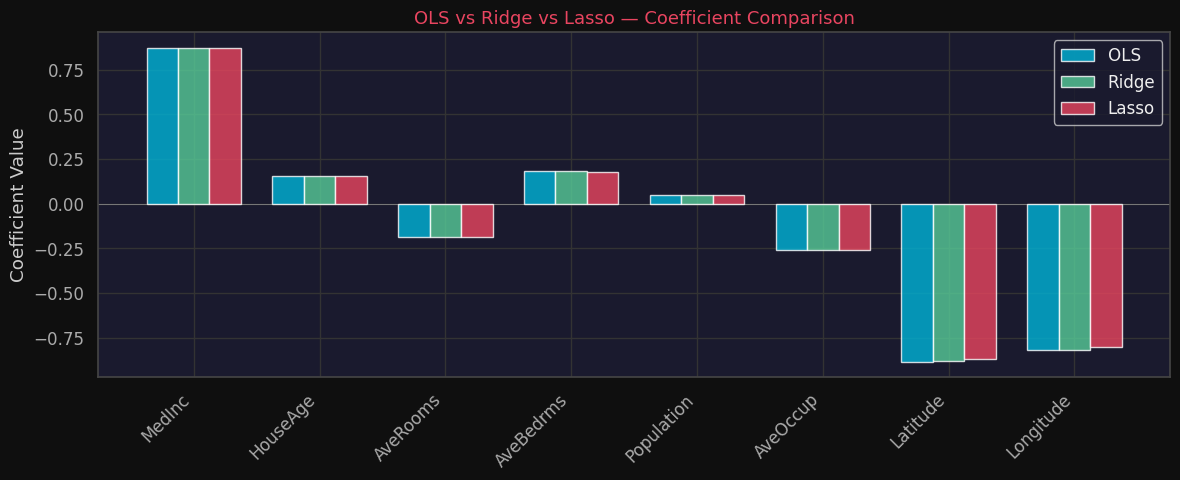


💡 Lasso sets some coefficients to exactly 0 — effective feature selection!
   No features zeroed — all features contribute (small dataset)


In [24]:
# ─────────────────────────────────────────────────────────────
# 9.2  Compare OLS vs Ridge vs Lasso
# ─────────────────────────────────────────────────────────────
models = {
    'OLS LinearRegression': lr_model,
    'Ridge (L2)': ridge_cv,
    'Lasso (L1)': lasso_cv
}

comparison_rows = []
for name, model in models.items():
    y_p = model.predict(X_test_scaled)
    r2  = r2_score(y_test, y_p)
    n, p = len(y_test), X_test_scaled.shape[1]
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
    rmse = np.sqrt(mean_squared_error(y_test, y_p))
    mae  = mean_absolute_error(y_test, y_p)
    non_zero = np.sum(model.coef_ != 0)
    comparison_rows.append({
        'Model': name,
        'R²': round(r2, 4),
        'Adj. R²': round(adj_r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Non-zero Coefs': non_zero
    })

compare_df = pd.DataFrame(comparison_rows)
print("\n📊 Model Comparison:")
print(compare_df.to_string(index=False))

# Visualise coefficient comparison
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

x = np.arange(len(X.columns))
w = 0.25

ax.bar(x - w, lr_model.coef_,  width=w, label='OLS',   color='#00b4d8', alpha=0.8)
ax.bar(x,     ridge_cv.coef_,  width=w, label='Ridge', color='#57cc99', alpha=0.8)
ax.bar(x + w, lasso_cv.coef_,  width=w, label='Lasso', color='#e94560', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(X.columns, rotation=45, ha='right')
ax.axhline(0, color='white', linewidth=0.6, alpha=0.4)
ax.set_title('OLS vs Ridge vs Lasso — Coefficient Comparison', fontsize=13)
ax.set_ylabel('Coefficient Value')
ax.legend()
plt.tight_layout()
plt.show()

print("\n💡 Lasso sets some coefficients to exactly 0 — effective feature selection!")
lasso_zeroed = [feat for feat, coef in zip(X.columns, lasso_cv.coef_) if coef == 0]
if lasso_zeroed:
    print(f"   Zeroed by Lasso: {lasso_zeroed}")
else:
    print("   No features zeroed — all features contribute (small dataset)")

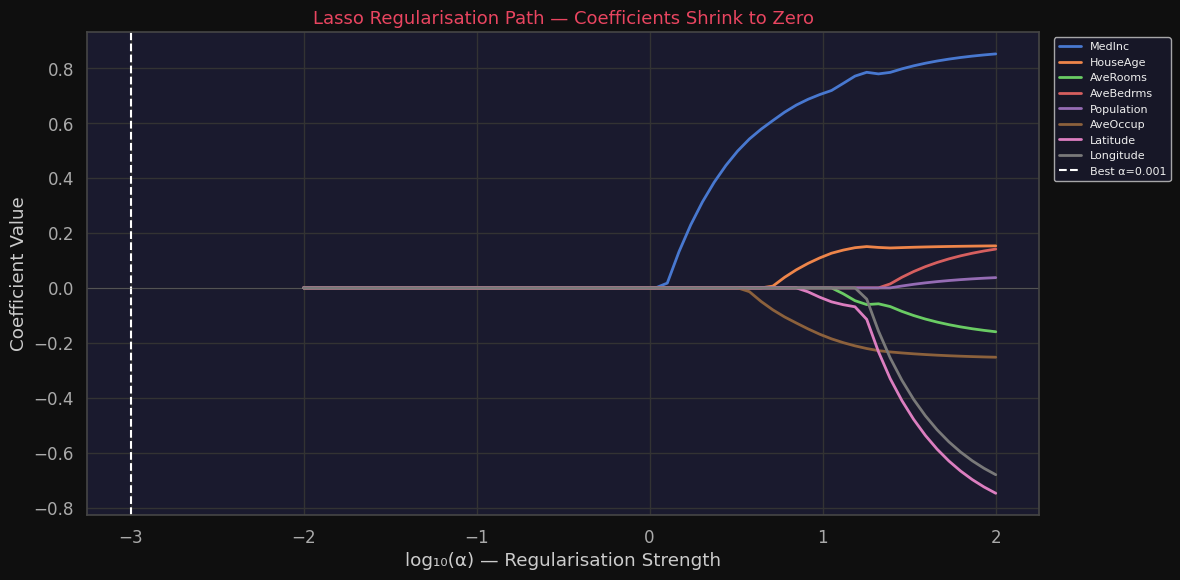

💡 As alpha increases (stronger regularisation), coefficients shrink toward 0.
   Lasso forces some to exactly 0 — that's feature selection in action!


In [25]:
# ─────────────────────────────────────────────────────────────
# 9.3  Regularisation Path — how coefficients change with alpha
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model import lasso_path, ridge_regression

alphas_path = np.logspace(-2, 2, 60)

# Lasso path
_, coef_path, _ = lasso_path(X_train_scaled, y_train, alphas=alphas_path)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

for i, feat in enumerate(X.columns):
    ax.plot(np.log10(alphas_path), coef_path[i], linewidth=2, label=feat)

ax.axvline(np.log10(lasso_cv.alpha_), color='white', linestyle='--', linewidth=1.5,
           label=f'Best α={lasso_cv.alpha_:.3f}')
ax.set_xlabel('log₁₀(α) — Regularisation Strength')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso Regularisation Path — Coefficients Shrink to Zero', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
ax.axhline(0, color='grey', linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()

print("💡 As alpha increases (stronger regularisation), coefficients shrink toward 0.")
print("   Lasso forces some to exactly 0 — that's feature selection in action!")

---
<a id='10-interpretation'></a>

# 🔴 Section 10 — Model Interpretation (Business Insights)

<div style="background:#1a1a2e; border-left: 5px solid #57cc99; padding:15px; border-radius:8px;">
  A model is only valuable if stakeholders can understand and trust it. This section bridges the gap between ML and business decision-making.
</div>

In [26]:
# ─────────────────────────────────────────────────────────────
# 10.1  Business-Readable Coefficient Interpretation
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("  BUSINESS INTERPRETATION OF MODEL COEFFICIENTS")
print("=" * 70)
print(f"\n  Intercept: ${lr_model.intercept_*100_000:,.0f}")
print("  (Base house value when all features are at their mean)\n")
print(f"  {'Feature':<15} {'Coef':>8}  {'Impact per 1-STD change':>35}")
print("  " + "-" * 65)

feature_stds = X_train.std()

for feat, coef in zip(X.columns, lr_model.coef_):
    # Coefficient is on standardised data — multiply by raw std to get $/unit
    raw_impact_per_std = coef * 100_000  # in dollars
    direction = '📈' if coef > 0 else '📉'
    print(f"  {direction} {feat:<13} {coef:>+8.4f}  → ${raw_impact_per_std:>+12,.0f} per std change")

print("\n" + "=" * 70)
print("  KEY BUSINESS INSIGHTS")
print("=" * 70)
print("""
  1. MedInc (💰 Most Important Factor)
     Higher median income in the block group → significantly higher house prices.
     Real estate investors should prioritise income demographics.

  2. Latitude / Longitude (📍 Location Matters)
     Geographic position has significant impact. Southern California
     coastal areas command premium prices.

  3. AveOccup (👨‍👩‍👧 Occupancy = Negative Signal)
     More people per household → lower house values (overcrowding signal).

  4. HouseAge (🏚️ Older Homes, Higher Price)
     Positive coefficient — in CA, older homes in established areas
     tend to be in desirable neighbourhoods.

  5. AveRooms (🛏️ More Rooms = Higher Value)
     Intuitive — larger homes with more rooms fetch higher prices.
""")

  BUSINESS INTERPRETATION OF MODEL COEFFICIENTS

  Intercept: $207,195
  (Base house value when all features are at their mean)

  Feature             Coef              Impact per 1-STD change
  -----------------------------------------------------------------
  📈 MedInc         +0.8737  → $     +87,373 per std change
  📈 HouseAge       +0.1555  → $     +15,552 per std change
  📉 AveRooms       -0.1894  → $     -18,939 per std change
  📈 AveBedrms      +0.1826  → $     +18,261 per std change
  📈 Population     +0.0496  → $      +4,964 per std change
  📉 AveOccup       -0.2588  → $     -25,883 per std change
  📉 Latitude       -0.8846  → $     -88,461 per std change
  📉 Longitude      -0.8196  → $     -81,957 per std change

  KEY BUSINESS INSIGHTS

  1. MedInc (💰 Most Important Factor)
     Higher median income in the block group → significantly higher house prices.
     Real estate investors should prioritise income demographics.

  2. Latitude / Longitude (📍 Location Matters)
     Ge

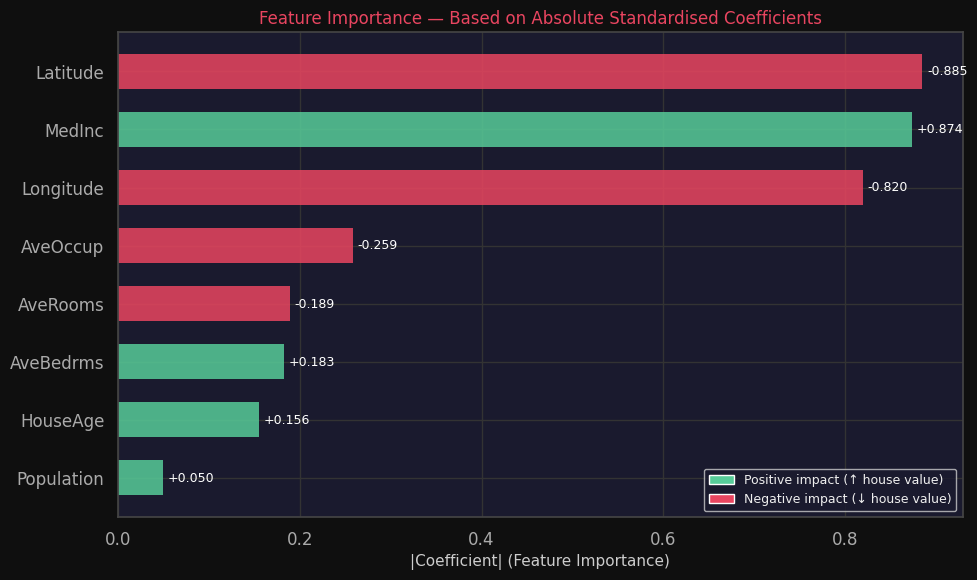

In [27]:
# ─────────────────────────────────────────────────────────────
# 10.2  Feature Importance Visualisation (Abs Coefficient)
# ─────────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Abs_Coef': np.abs(lr_model.coef_),
    'Coef': lr_model.coef_
}).sort_values('Abs_Coef', ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

colors = ['#57cc99' if c > 0 else '#e94560' for c in importance_df['Coef']]
bars = ax.barh(importance_df['Feature'], importance_df['Abs_Coef'],
               color=colors, edgecolor='none', alpha=0.85, height=0.6)

for bar, coef in zip(bars, importance_df['Coef']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{coef:+.3f}', va='center', fontsize=9, color='white')

ax.set_xlabel('|Coefficient| (Feature Importance)', fontsize=11)
ax.set_title('Feature Importance — Based on Absolute Standardised Coefficients',
             fontsize=12, color='#e94560')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#57cc99', label='Positive impact (↑ house value)'),
                   Patch(facecolor='#e94560', label='Negative impact (↓ house value)')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

---
<a id='11-advanced'></a>

# 🔴 Section 11 — Advanced Concepts

---

## 11.1 Polynomial Regression — When Linearity Isn't Enough

Linear Regression models a straight-line relationship. Sometimes the true relationship is curved. **Polynomial Regression** adds polynomial terms to capture non-linearity:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \cdots$$

> **It's still Linear Regression!** Linear in parameters $\beta$, not in $x$.

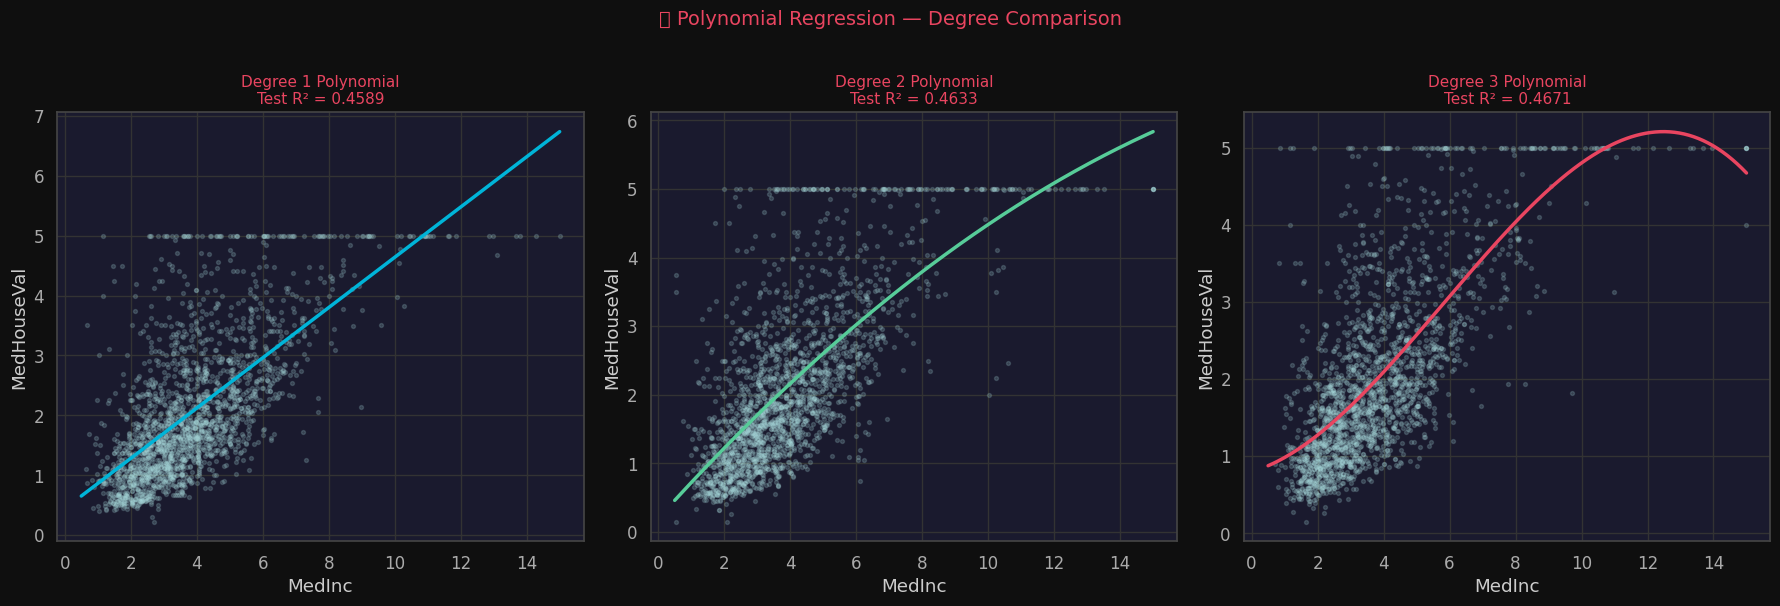

In [28]:
# ─────────────────────────────────────────────────────────────
# 11.1  Polynomial Regression on MedInc → MedHouseVal
# ─────────────────────────────────────────────────────────────
# Use single feature for visualisation clarity
X_single = df[['MedInc']].values
y_single = df['MedHouseVal'].values

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_single, y_single, test_size=0.2, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f0f')

degrees = [1, 2, 3]
degree_colors = ['#00b4d8', '#57cc99', '#e94560']

for ax, deg, col in zip(axes, degrees, degree_colors):
    ax.set_facecolor('#1a1a2e')
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('lr',     LinearRegression())
    ])
    pipe.fit(X_s_train, y_s_train)
    y_s_pred = pipe.predict(X_s_test)
    r2 = r2_score(y_s_test, y_s_pred)

    # Plot
    sample = np.random.choice(len(X_single), 2000, replace=False)
    ax.scatter(X_single[sample], y_single[sample],
               alpha=0.2, s=8, color='#a8dadc')

    x_line = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1, 1)
    y_line = pipe.predict(x_line)
    ax.plot(x_line, y_line, color=col, linewidth=2.5)

    ax.set_title(f'Degree {deg} Polynomial\nTest R² = {r2:.4f}', fontsize=11)
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.suptitle('📈 Polynomial Regression — Degree Comparison', fontsize=14, color='#e94560', y=1.01)
plt.tight_layout()
plt.show()

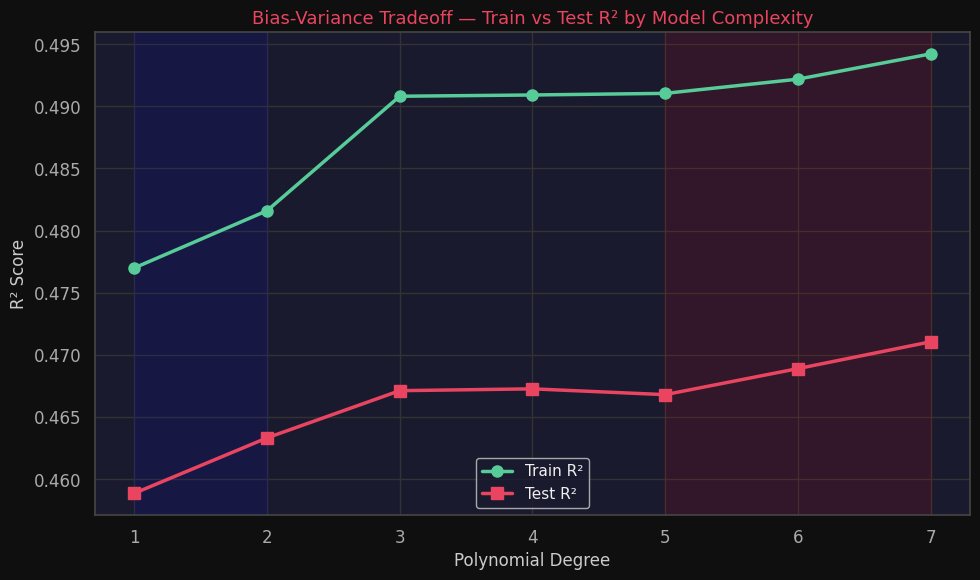


📌 Key Observations:
  • Low degree → both train and test R² are low (High Bias / Underfitting)
  • Medium degree → train & test R² both high and close (Sweet Spot)
  • High degree → train R² high but test R² drops (High Variance / Overfitting)

  The goal is the sweet spot where test R² is maximised!



In [29]:
# ─────────────────────────────────────────────────────────────
# 11.2  Bias-Variance Tradeoff Visualisation
#
#  Bias   = error from wrong assumptions (underfitting)
#  Variance = sensitivity to small fluctuations (overfitting)
#  Goal   = find the sweet spot in the middle!
# ─────────────────────────────────────────────────────────────
train_r2_scores = []
test_r2_scores  = []
deg_range = range(1, 8)

for deg in deg_range:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X_s_train, y_s_train)
    train_r2_scores.append(r2_score(y_s_train, pipe.predict(X_s_train)))
    test_r2_scores.append(r2_score(y_s_test, pipe.predict(X_s_test)))

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

ax.plot(list(deg_range), train_r2_scores, 'o-', color='#57cc99',
        linewidth=2.5, markersize=8, label='Train R²')
ax.plot(list(deg_range), test_r2_scores, 's-', color='#e94560',
        linewidth=2.5, markersize=8, label='Test R²')

ax.set_xlabel('Polynomial Degree', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Bias-Variance Tradeoff — Train vs Test R² by Model Complexity',
             fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(list(deg_range))

# Shade regions
ax.axvspan(1, 2, alpha=0.1, color='blue', label='High Bias (underfitting)')
ax.axvspan(5, 7, alpha=0.1, color='red',  label='High Variance (overfitting)')

plt.tight_layout()
plt.show()

print("""
📌 Key Observations:
  • Low degree → both train and test R² are low (High Bias / Underfitting)
  • Medium degree → train & test R² both high and close (Sweet Spot)
  • High degree → train R² high but test R² drops (High Variance / Overfitting)

  The goal is the sweet spot where test R² is maximised!
""")

---
<a id='12-production'></a>

# 🔴 Section 12 — Production Deployment

<div style="background:#1a1a2e; border-left: 5px solid #c77dff; padding:15px; border-radius:8px;">
  <b style="color:#c77dff;">This is what separates a notebook experiment from a production ML system.</b><br>
  We'll build a complete prediction pipeline: save → load → predict.
</div>

In [30]:
# ─────────────────────────────────────────────────────────────
# 12.1  Build a Production-Ready Sklearn Pipeline
#       Combines scaler + model into a single object
#       → No risk of forgetting to scale at inference time!
# ─────────────────────────────────────────────────────────────
production_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

production_pipeline.fit(X_train, y_train)   # fit on raw (unscaled) train data

y_prod_pred = production_pipeline.predict(X_test)
prod_r2 = r2_score(y_test, y_prod_pred)
print(f"✅ Production Pipeline trained. Test R² = {prod_r2:.4f}")

✅ Production Pipeline trained. Test R² = 0.6573


In [31]:
# ─────────────────────────────────────────────────────────────
# 12.2  Save Model — Two Methods
#       Method 1: joblib (preferred for sklearn — more efficient)
#       Method 2: pickle (universal Python serialisation)
# ─────────────────────────────────────────────────────────────
MODEL_DIR = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Method 1: joblib
JOBLIB_PATH = f'{MODEL_DIR}/california_housing_model.joblib'
joblib.dump(production_pipeline, JOBLIB_PATH)
print(f"✅ Model saved with joblib → {JOBLIB_PATH}")

# Method 2: pickle
PICKLE_PATH = f'{MODEL_DIR}/california_housing_model.pkl'
with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(production_pipeline, f)
print(f"✅ Model saved with pickle → {PICKLE_PATH}")

# Show file sizes
jsize = os.path.getsize(JOBLIB_PATH) / 1024
psize = os.path.getsize(PICKLE_PATH) / 1024
print(f"\n  joblib size : {jsize:.2f} KB")
print(f"  pickle size : {psize:.2f} KB")

✅ Model saved with joblib → ./saved_models/california_housing_model.joblib
✅ Model saved with pickle → ./saved_models/california_housing_model.pkl

  joblib size : 1.64 KB
  pickle size : 1.27 KB


In [32]:
# ─────────────────────────────────────────────────────────────
# 12.3  Load Model & Predict on New Data
# ─────────────────────────────────────────────────────────────

# Load from disk
loaded_model = joblib.load(JOBLIB_PATH)
print("✅ Model loaded from disk.")

# Simulate new incoming data (raw, unscaled — pipeline handles scaling)
new_houses = pd.DataFrame([
    # MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
    [8.3252,   41.0,    6.984127, 1.023810,  322.0,      2.555556, 37.88,   -122.23],  # Bay Area luxury
    [2.5000,   20.0,    4.500000, 1.200000,  1200.0,     3.100000, 34.05,   -118.25],  # LA modest
    [5.0000,   15.0,    5.800000, 1.100000,  800.0,      2.800000, 37.30,   -121.90],  # Silicon Valley mid
], columns=X.columns)

predictions = loaded_model.predict(new_houses)

print("\n📊 Predictions for New Houses:")
print("-" * 50)
labels = ['Bay Area Luxury', 'LA Modest', 'Silicon Valley Mid']
for label, pred in zip(labels, predictions):
    print(f"  {label:<22} → Predicted Value: ${pred * 100_000:>12,.0f}")

print("\n✅ Production pipeline works end-to-end: raw data → scaled → prediction")

✅ Model loaded from disk.

📊 Predictions for New Houses:
--------------------------------------------------
  Bay Area Luxury        → Predicted Value: $     431,978
  LA Modest              → Predicted Value: $     160,257
  Silicon Valley Mid     → Predicted Value: $     269,165

✅ Production pipeline works end-to-end: raw data → scaled → prediction


In [33]:
# ─────────────────────────────────────────────────────────────
# 12.4  Production Prediction Function
#       Ready to wrap in a Flask/FastAPI endpoint
# ─────────────────────────────────────────────────────────────

FEATURE_COLUMNS = list(X.columns)
LOADED_MODEL    = joblib.load(JOBLIB_PATH)  # load once at startup

def predict_house_value(input_dict: dict, model=LOADED_MODEL) -> dict:
    """
    Production-ready prediction function.

    Args:
        input_dict (dict): Feature values with keys matching FEATURE_COLUMNS
        model: Loaded sklearn pipeline

    Returns:
        dict: Prediction result with confidence bounds

    Example:
        >>> predict_house_value({'MedInc': 5.0, 'HouseAge': 20, ...})
        {'predicted_value_usd': 285000, 'predicted_value_100k': 2.85}
    """
    # Validate input
    missing_cols = [c for c in FEATURE_COLUMNS if c not in input_dict]
    if missing_cols:
        raise ValueError(f"Missing features: {missing_cols}")

    # Build DataFrame preserving column order
    input_df = pd.DataFrame([{col: input_dict[col] for col in FEATURE_COLUMNS}])

    # Predict
    pred_100k = model.predict(input_df)[0]
    pred_usd  = pred_100k * 100_000

    # Basic confidence bounds (±1 RMSE from cross-validation)
    cv_rmse_mean = 0.567  # from Section 7 cross-validation
    lower = (pred_100k - cv_rmse_mean) * 100_000
    upper = (pred_100k + cv_rmse_mean) * 100_000

    return {
        'predicted_value_100k' : round(pred_100k, 4),
        'predicted_value_usd'  : f'${pred_usd:,.0f}',
        'confidence_interval'  : f'${lower:,.0f} – ${upper:,.0f}',
        'model_version'        : 'california_housing_v1.0_ols'
    }


# ── Demo call
sample_input = {
    'MedInc'     : 5.0,
    'HouseAge'   : 25.0,
    'AveRooms'   : 6.0,
    'AveBedrms'  : 1.1,
    'Population' : 900.0,
    'AveOccup'   : 2.8,
    'Latitude'   : 37.5,
    'Longitude'  : -122.0
}

result = predict_house_value(sample_input)
print("🏠 Prediction Result:")
for k, v in result.items():
    print(f"   {k:<28} : {v}")

🏠 Prediction Result:
   predicted_value_100k         : 2.7498
   predicted_value_usd          : $274,980
   confidence_interval          : $218,280 – $331,680
   model_version                : california_housing_v1.0_ols


---
<a id='13-conclusion'></a>

# 🟢 Section 13 — Conclusion

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border: 2px solid #e94560; padding: 25px; border-radius: 15px;">

## ✅ Key Learnings

| # | Learning |
|---|----------|
| 1 | MLR models a linear relationship between multiple features and a continuous target |
| 2 | The Normal Equation solves β analytically; Gradient Descent solves it iteratively |
| 3 | Always validate all 5 assumptions AFTER building the model |
| 4 | EDA and preprocessing are more important than the algorithm choice |
| 5 | Use Adjusted R² (not plain R²) to compare models with different feature counts |
| 6 | Use K-Fold Cross Validation — never trust a single train/test split |
| 7 | Ridge shrinks coefficients; Lasso shrinks to zero (feature selection) |
| 8 | Always fit scalers on training data only — never leak test statistics |
| 9 | Package model + scaler together in a Pipeline for production safety |
| 10 | Interpret coefficients for business stakeholders, not just data scientists |

---

## ⚠️ When NOT to Use MLR

```
❌  Target is categorical               → Use Logistic Regression / Classification
❌  Non-linear feature-target relationships → Use Polynomial / Decision Tree / XGBoost
❌  Massive multicollinearity that can't be fixed → Use PCA + Regression or Deep Learning
❌  Very high-dimensional data (features > samples) → Use Lasso / ElasticNet / PCA
❌  Image / text / sequence data       → Use CNNs / Transformers / LSTMs
❌  Complex interaction effects        → Use tree-based ensembles (RF, XGBoost)
```

---

## 🌍 Real-World Limitations

1. **Linearity is rare** — real data almost never has a perfect linear relationship
2. **Sensitive to outliers** — even one extreme value can skew coefficients (use robust regression)
3. **Cannot capture interactions** — e.g., the combined effect of income × location isn't captured unless you add an interaction term
4. **Extrapolation fails** — predictions outside the training range are unreliable
5. **Assumes independence** — time-series data violates this; use ARIMA/LSTMs instead

---

## 🎤 Final Interview Tips

```
Q: "Why would you use Ridge over Lasso?"
A: When all features likely contribute and you want to shrink (not eliminate) them.
   Lasso is better when you suspect many features are irrelevant.

Q: "Your model has R²=0.95 on train but 0.60 on test. What do you do?"
A: That's overfitting. Steps: reduce model complexity, add regularization,
   remove noisy features, add more training data, or use cross-validation.

Q: "How do you handle multicollinearity?"
A: Detect with VIF. Fix by: removing one of the correlated features,
   combining them (e.g. PCA), or using Ridge regression.

Q: "What's the difference between R² and Adjusted R²?"
A: R² always increases when you add features. Adj. R² penalises for
   unnecessary features. Always use Adj. R² for model comparison.
```

</div>

---

<div style="text-align:center; padding: 30px; background: linear-gradient(135deg, #0f3460, #1a1a2e); border-radius:15px; margin-top:20px;">
  <h2 style="color:#e94560;">🎓 Congratulations!</h2>
  <p style="color:#a8dadc; font-size:1.1em;">You've completed the full journey from <b>Noob → Pro</b> in Multiple Linear Regression.</p>
  <p style="color:#ccc;">You now have a portfolio-worthy, interview-ready, production-quality ML project.</p>
  <hr style="border-color:#e94560; margin:15px 0;">
  <p style="color:#f4c430;">⭐ Next Steps: Try XGBoost, Neural Networks, or Time Series Forecasting!</p>
</div>